In [3]:
from pathlib import Path
import json
import pandas as pd

summary_path = Path("/home/akapociu/ift/interactiondynamics/results/mini_sweep_summary_6ep_3seeds.jsonl") 

rows = []
with open(summary_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

len(rows)

75

In [4]:
def parse_name(name):
    parts = {}
    for piece in name.split("|"):
        if "=" in piece:
            k, v = piece.split("=", 1)
            parts[k] = v
    return parts

flat_rows = []
for r in rows:
    name_parts = parse_name(r["name"])
    
    row = {
        "name": r["name"],
        "seed": r["seed"],
        "epochs": r["epochs"],
        "wall_sec": r.get("wall_sec"),
        "best_epoch": r.get("best_epoch"),
        "best_val_mrr": r.get("best_val_mrr"),
        
        "aggregator": name_parts.get("agg"),
        "update": name_parts.get("update"),
        "dropout": float(name_parts.get("do")) if name_parts.get("do") is not None else None,
        "scorer_dropout": float(name_parts.get("sdo")) if name_parts.get("sdo") is not None else None,
        "time_features": name_parts.get("time"),
    }
    
    best = r.get("best_snapshot", {})
    final = r.get("final_snapshot", {})
    
    row.update({
        "best_val_loss": best.get("val", {}).get("loss"),
        "best_val_mrr_from_snapshot": best.get("val", {}).get("mrr"),
        "best_test_mrr": best.get("test", {}).get("mrr"),
        "best_test_loss": best.get("test", {}).get("loss"),
        "best_train_mrr": best.get("train_eval", {}).get("mrr"),

        "best_val_early_mrr": best.get("val", {}).get("early_mrr"),
        "best_val_late_mrr": best.get("val", {}).get("late_mrr"),
        "best_test_early_mrr": best.get("test", {}).get("early_mrr"),
        "best_test_late_mrr": best.get("test", {}).get("late_mrr"),

        "final_val_mrr": final.get("val", {}).get("mrr"),
        "final_test_mrr": final.get("test", {}).get("mrr"),
        "final_train_mrr": final.get("train_eval", {}).get("mrr"),
    })
    
    flat_rows.append(row)

df = pd.DataFrame(flat_rows)
df.head()

,name,seed,epochs,wall_sec,best_epoch,best_val_mrr,aggregator,update,dropout,scorer_dropout,...,best_test_mrr,best_test_loss,best_train_mrr,best_val_early_mrr,best_val_late_mrr,best_test_early_mrr,best_test_late_mrr,final_val_mrr,final_test_mrr,final_train_mrr
0,agg=ift|update=ift_update|do=0.0|sdo=0.0|time=...,0,6,46.883135,1,0.815845,ift,ift_update,0.0,0.0,...,0.829217,1.592599,0.809153,0.870123,0.810417,0.897498,0.822522,0.812531,0.828198,0.769162
1,agg=ift|update=ift_update|do=0.0|sdo=0.0|time=...,42,6,46.333431,1,0.815885,ift,ift_update,0.0,0.0,...,0.828340,1.583759,0.809597,0.864658,0.811007,0.892761,0.822024,0.807490,0.827575,0.766862
2,agg=ift|update=ift_update|do=0.0|sdo=0.0|time=...,123,6,46.239935,1,0.814628,ift,ift_update,0.0,0.0,...,0.826385,1.565842,0.810698,0.870105,0.809080,0.888567,0.820289,0.814423,0.827753,0.768288
3,agg=ift|update=tgn_gru|do=0.0|sdo=0.0|time=False,0,6,40.995564,2,0.859029,ift,tgn_gru,0.0,0.0,...,0.865719,0.999022,0.865167,0.897263,0.855205,0.909579,0.861420,0.858047,0.862447,0.864363
4,agg=ift|update=tgn_gru|do=0.0|sdo=0.0|time=False,42,6,41.302504,4,0.860116,ift,tgn_gru,0.0,0.0,...,0.865342,0.862326,0.866047,0.899990,0.856129,0.903453,0.861606,0.857225,0.863247,0.864763


In [5]:
config_cols = ["aggregator", "update", "dropout", "scorer_dropout", "time_features"]
df["config_id"] = df[config_cols].astype(str).agg("|".join, axis=1)

In [6]:
summary = (
    df.groupby("config_id")
      .agg(
          n_seeds=("seed", "count"),
          mean_best_val_mrr=("best_val_mrr", "mean"),
          std_best_val_mrr=("best_val_mrr", "std"),
          mean_best_test_mrr=("best_test_mrr", "mean"),
          std_best_test_mrr=("best_test_mrr", "std"),
          mean_final_test_mrr=("final_test_mrr", "mean"),
          mean_wall_sec=("wall_sec", "mean"),
      )
      .sort_values("mean_best_val_mrr", ascending=False)
)

summary.head(15)

,n_seeds,mean_best_val_mrr,std_best_val_mrr,mean_best_test_mrr,std_best_test_mrr,mean_final_test_mrr,mean_wall_sec
config_id,,,,,,,
ift|tgn_gru|0.0|0.0|False,3,0.859373,0.000644,0.864919,0.001077,0.863130,41.205585
sum|hopfield_update|0.0|0.0|False,3,0.857482,0.008532,0.854569,0.011011,0.805503,388.438757
ift|hopfield_update|0.0|0.0|False,3,0.855271,0.002698,0.859323,0.001258,0.804051,397.211020
sum|tgn_gru|0.0|0.0|False,3,0.847738,0.016192,0.847369,0.014555,0.823468,31.586020
settransformer|hopfield_update|0.0|0.0|False,3,0.841935,0.013559,0.839650,0.014128,0.839650,445.420083
settransformer|tgn_gru|0.0|0.0|False,3,0.837348,0.012149,0.837820,0.011854,0.815526,64.335989
deepsets|hopfield_update|0.0|0.0|False,3,0.836608,0.008666,0.830291,0.016472,0.773628,392.982212
hopfield|tgn_gru|0.0|0.0|False,3,0.825241,0.001610,0.825930,0.000900,0.820692,44.901183
hopfield|hopfield_update|0.0|0.0|False,3,0.822390,0.008600,0.820832,0.006123,0.764743,424.602266


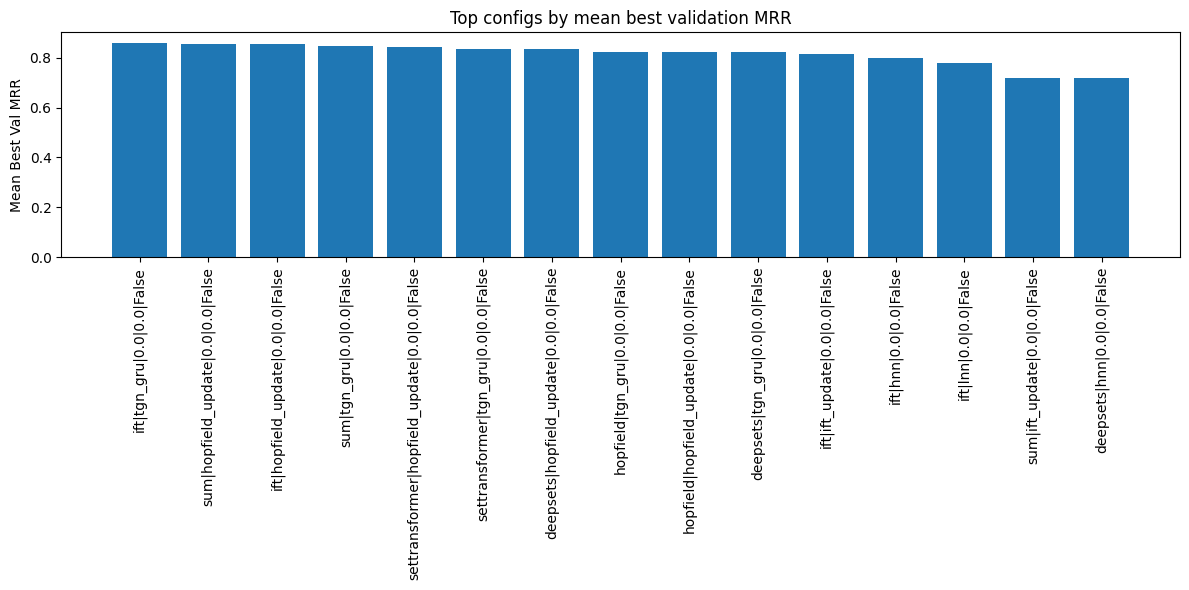

In [7]:
import matplotlib.pyplot as plt

top = summary.head(15)

plt.figure(figsize=(12, 6))
plt.bar(top.index, top["mean_best_val_mrr"])
plt.xticks(rotation=90)
plt.ylabel("Mean Best Val MRR")
plt.title("Top configs by mean best validation MRR")
plt.tight_layout()
plt.show()

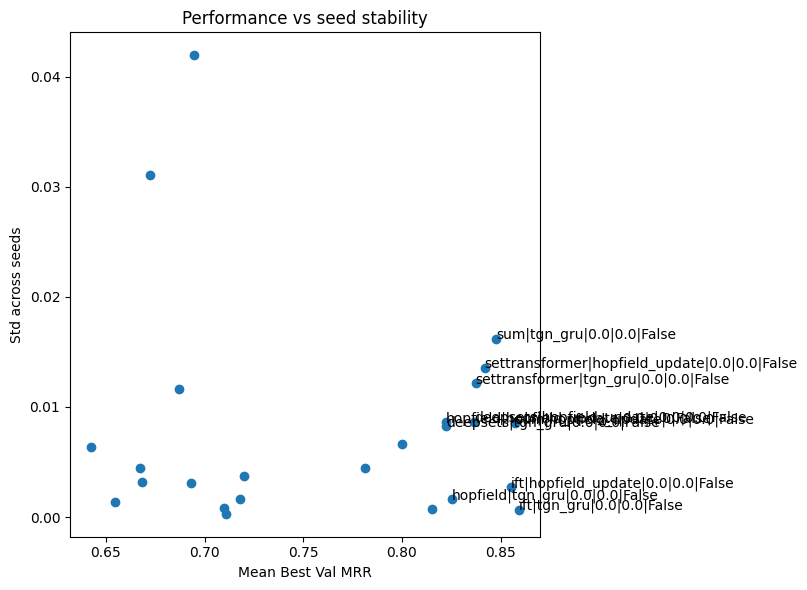

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(summary["mean_best_val_mrr"], summary["std_best_val_mrr"].fillna(0))

for config, row in summary.head(10).iterrows():
    plt.annotate(config, (row["mean_best_val_mrr"], row["std_best_val_mrr"] if pd.notna(row["std_best_val_mrr"]) else 0))

plt.xlabel("Mean Best Val MRR")
plt.ylabel("Std across seeds")
plt.title("Performance vs seed stability")
plt.tight_layout()
plt.show()

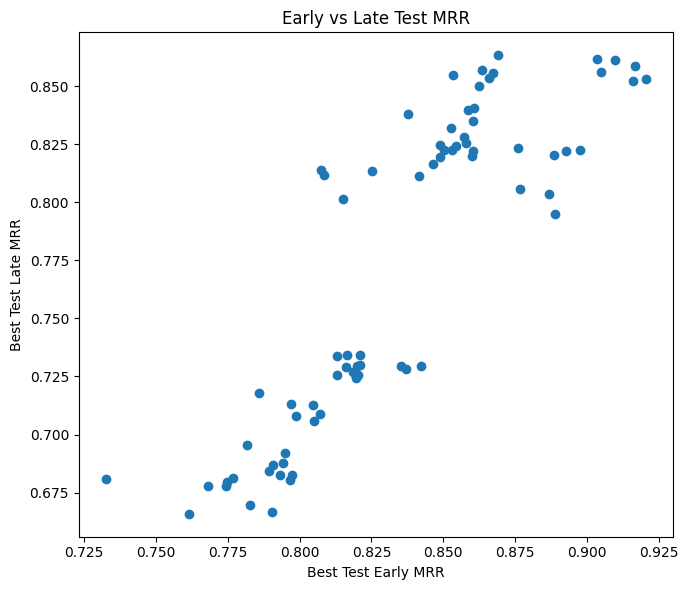

In [9]:
plt.figure(figsize=(7, 6))
plt.scatter(df["best_test_early_mrr"], df["best_test_late_mrr"])

plt.xlabel("Best Test Early MRR")
plt.ylabel("Best Test Late MRR")
plt.title("Early vs Late Test MRR")
plt.tight_layout()
plt.show()

In [10]:
summary.reset_index()[[
    "config_id",
    "n_seeds",
    "mean_best_val_mrr",
    "std_best_val_mrr",
    "mean_best_test_mrr",
    "std_best_test_mrr",
    "mean_final_test_mrr",
    "mean_wall_sec",
]].head(20)

,config_id,n_seeds,mean_best_val_mrr,std_best_val_mrr,mean_best_test_mrr,std_best_test_mrr,mean_final_test_mrr,mean_wall_sec
0,ift|tgn_gru|0.0|0.0|False,3,0.859373,0.000644,0.864919,0.001077,0.863130,41.205585
1,sum|hopfield_update|0.0|0.0|False,3,0.857482,0.008532,0.854569,0.011011,0.805503,388.438757
2,ift|hopfield_update|0.0|0.0|False,3,0.855271,0.002698,0.859323,0.001258,0.804051,397.211020
3,sum|tgn_gru|0.0|0.0|False,3,0.847738,0.016192,0.847369,0.014555,0.823468,31.586020
4,settransformer|hopfield_update|0.0|0.0|False,3,0.841935,0.013559,0.839650,0.014128,0.839650,445.420083
5,settransformer|tgn_gru|0.0|0.0|False,3,0.837348,0.012149,0.837820,0.011854,0.815526,64.335989
6,deepsets|hopfield_update|0.0|0.0|False,3,0.836608,0.008666,0.830291,0.016472,0.773628,392.982212
7,hopfield|tgn_gru|0.0|0.0|False,3,0.825241,0.001610,0.825930,0.000900,0.820692,44.901183
8,hopfield|hopfield_update|0.0|0.0|False,3,0.822390,0.008600,0.820832,0.006123,0.764743,424.602266
9,deepsets|tgn_gru|0.0|0.0|False,3,0.822302,0.008267,0.814628,0.010562,0.770233,37.454459
